In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor

In [ ]:
SEED = 42

In [ ]:
!unzip "/content/playground-series-s5e2.zip"

Archive:  /content/playground-series-s5e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
  inflating: training_extra.csv      


In [ ]:
train_data = pd.concat([pd.read_csv("train.csv"),
                        pd.read_csv("training_extra.csv")])
train_data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...,...
3694313,4194313,Nike,Canvas,NaN,3.0,Yes,Yes,Messenger,Blue,28.098120,104.74460
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,122.39043
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,148.18470
3694316,4194316,Puma,Canvas,NaN,2.0,No,No,Backpack,Gray,28.783339,22.32269


In [ ]:
train_data = train_data.dropna()

## Explore data

In [ ]:
cat_features = []
for column in train_data.columns:
    if train_data[column].dtype == 'O':
        print(column, ": ", train_data[column].unique())
        cat_features.append(column)

Brand :  ['Jansport' 'Under Armour' 'Nike' 'Adidas' 'Puma' nan]
Material :  ['Leather' 'Canvas' 'Nylon' nan 'Polyester']
Size :  ['Medium' 'Small' 'Large' nan]
Laptop Compartment :  ['Yes' 'No' nan]
Waterproof :  ['No' 'Yes' nan]
Style :  ['Tote' 'Messenger' nan 'Backpack']
Color :  ['Black' 'Green' 'Red' 'Blue' 'Gray' 'Pink' nan]


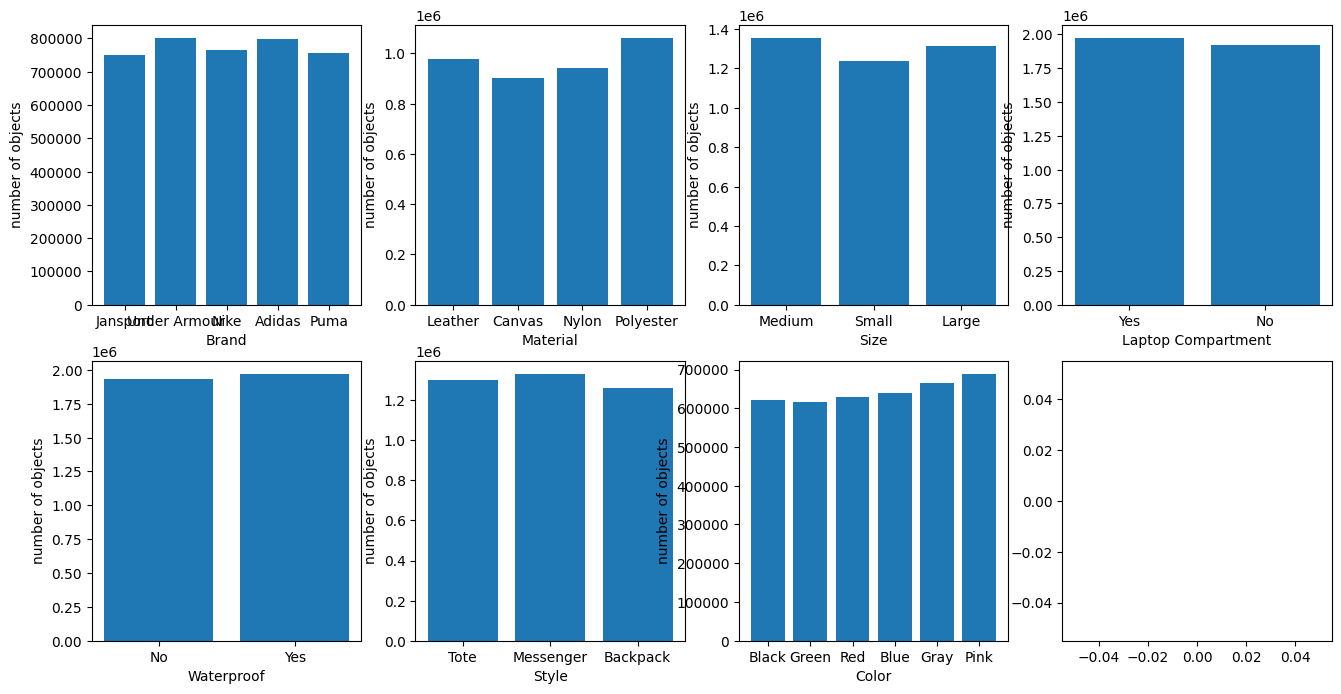

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, axis in enumerate(axes.flat):
    if i == 7:
        axis.plot([0])
    else:
        names = train_data[cat_features[i]].dropna().unique()
        values = train_data[cat_features[i]].value_counts(sort=False).values
        axis.bar(names,
                values)
        axis.set_xlabel(cat_features[i])
        axis.set_ylabel('number of objects')

count    300000.000000
mean         81.411107
std          39.039340
min          15.000000
25%          47.384620
50%          80.956120
75%         115.018160
max         150.000000
Name: Price, dtype: float64


<ipython-input-7-a1e32c23478e>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['Price'], color='g', bins=100, hist_kws={'alpha': 0.4});


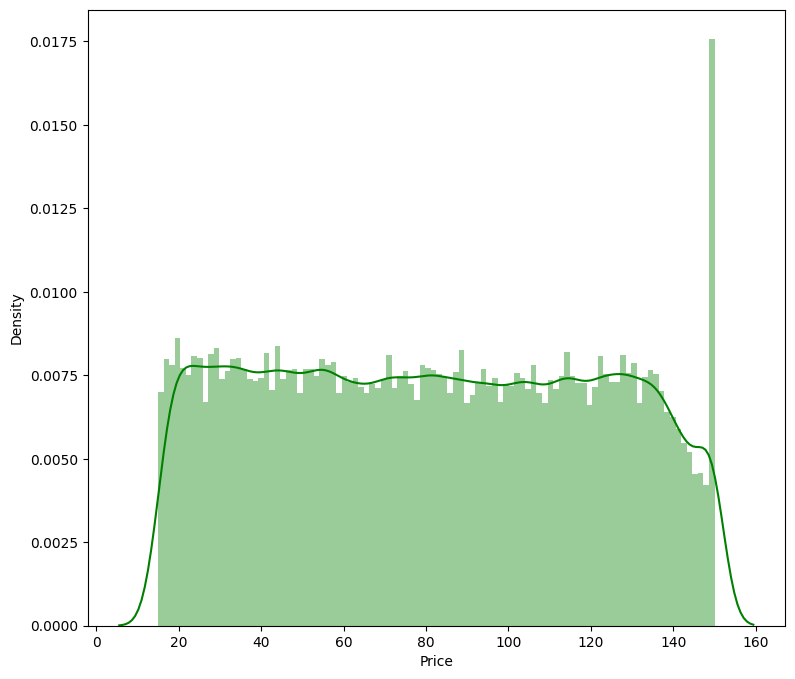

In [ ]:
print(train_data['Price'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(train_data['Price'], color='g', bins=100, hist_kws={'alpha': 0.4});

count    3.994318e+06
mean     5.434740e+00
std      2.893043e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      1.000000e+01
Name: Compartments, dtype: float64


<ipython-input-12-156ce8e0ff35>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['Compartments'], color='g', bins=100, hist_kws={'alpha': 0.4});


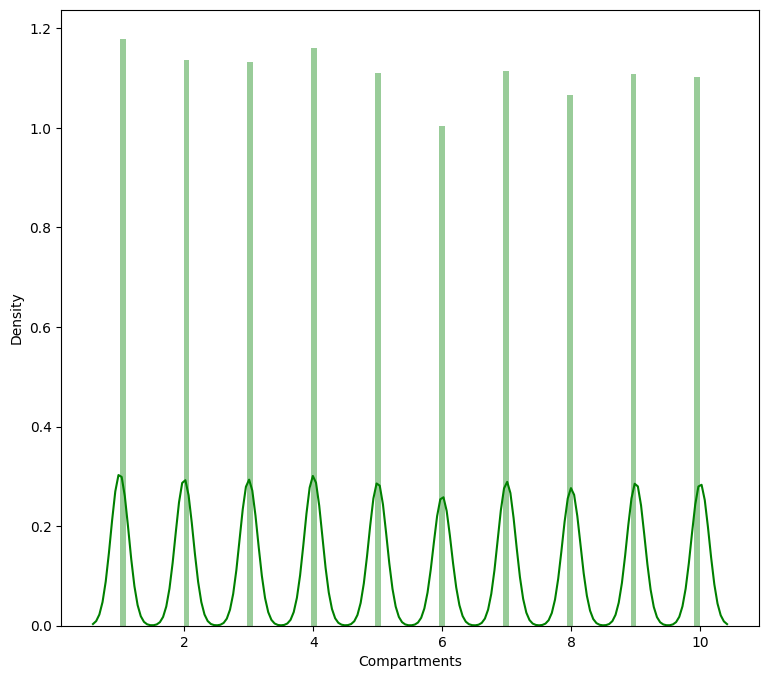

In [ ]:
print(train_data['Compartments'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(train_data['Compartments'], color='g', bins=100, hist_kws={'alpha': 0.4});

count    3.992510e+06
mean     1.801042e+01
std      6.973969e+00
min      5.000000e+00
25%      1.206896e+01
50%      1.805436e+01
75%      2.398751e+01
max      3.000000e+01
Name: Weight Capacity (kg), dtype: float64


<ipython-input-14-58848eb325c7>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['Weight Capacity (kg)'], color='g', bins=100, hist_kws={'alpha': 0.4});


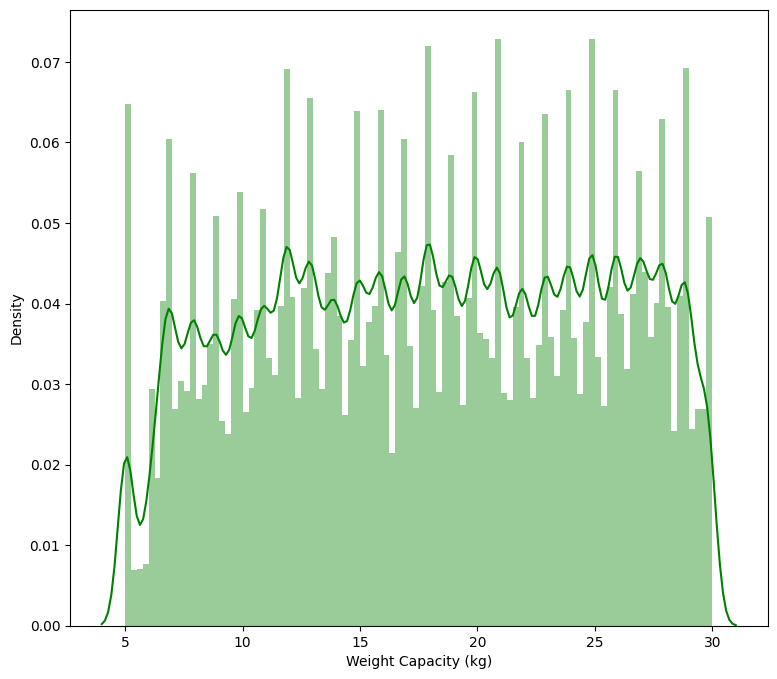

In [ ]:
print(train_data['Weight Capacity (kg)'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(train_data['Weight Capacity (kg)'], color='g', bins=100, hist_kws={'alpha': 0.4});

In [ ]:
train_data[train_data["Price"] >= 150]

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price,Compartments_cat
111,111,Adidas,Canvas,Large,8.0,No,No,Messenger,Gray,18.629323,150.0,8.0
263,263,Jansport,Canvas,Large,7.0,No,No,Tote,Green,8.412719,150.0,7.0
278,278,Jansport,Nylon,NaN,2.0,Yes,No,NaN,Gray,28.125328,150.0,2.0
318,318,Nike,NaN,Large,3.0,No,Yes,Tote,Red,11.994718,150.0,3.0
333,333,Jansport,Leather,Large,1.0,Yes,Yes,Messenger,NaN,15.274816,150.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3694126,4194126,Nike,Leather,Large,6.0,Yes,Yes,Messenger,Blue,6.684283,150.0,6.0
3694155,4194155,Puma,Polyester,Small,8.0,No,No,Tote,Pink,23.882739,150.0,8.0
3694173,4194173,Adidas,Leather,Large,6.0,Yes,Yes,Tote,Black,26.878217,150.0,6.0
3694177,4194177,Puma,Nylon,Large,10.0,No,No,Tote,Black,27.163606,150.0,10.0


## Split

In [ ]:
# add Compartments as cat feature
# train_data.insert(10, "Compartments_cat", train_data["Compartments"].values.astype(str))
train_data.insert(10, "W+C", (train_data["Compartments"].values + train_data["Weight Capacity (kg)"].values).astype(float))
train_data.insert(11, "W*C", (train_data["Compartments"].values * train_data["Weight Capacity (kg)"].values).astype(float))
train_data.insert(12, "Price_clusters", train_data["Price"].values // 20)

In [ ]:
train_data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),W+C,W*C,Price_clusters,Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,18.611723,81.282060,5.0,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,37.078537,270.785366,3.0,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,18.643760,33.287520,1.0,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,20.937220,103.497762,4.0,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,18.749338,17.749338,4.0,86.02312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694311,4194311,Puma,Polyester,Medium,4.0,Yes,Yes,Messenger,Pink,28.425845,32.425845,113.703382,5.0,107.18468
3694312,4194312,Jansport,Polyester,Large,6.0,Yes,Yes,Backpack,Red,16.641739,22.641739,99.850432,1.0,31.52978
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,27.379531,173.795310,6.0,122.39043
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,27.037708,170.377078,7.0,148.18470


In [ ]:
X = train_data.iloc[:, :-1].values
y = train_data.iloc[:, -1].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(2959652, 13)
(328851, 13)


## Baseline

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())

In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.91044889852831

## Price >= 150

In [ ]:
X_test = train_data[train_data["Price"] >= 150].iloc[:, indexes].values
y_test = train_data[train_data["Price"] >= 150].iloc[:, -2].values

y_pred = lr_pipe.predict(X_test)
root_mean_squared_error(y_test, y_pred)

68.58137591735417

In [ ]:
X_test = train_data[train_data["Price"] < 150].iloc[:, indexes].values
y_test = train_data[train_data["Price"] < 150].iloc[:, -2].values

y_pred = lr_pipe.predict(X_test)
root_mean_squared_error(y_test, y_pred)

38.15048723815487

In [ ]:
X_train = train_data[train_data["Price"] >= 150].iloc[:, indexes].values
y_train = train_data[train_data["Price"] >= 150].iloc[:, -2].values

lr_pipe.fit(X_train, y_train);

X_test = train_data[train_data["Price"] < 150].iloc[:, indexes].values
y_test = train_data[train_data["Price"] < 150].iloc[:, -2].values

y_pred = lr_pipe.predict(X_test)
root_mean_squared_error(y_test, y_pred)

79.63550632679207

## Experiments

### Pipeline parameters

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())

In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.922189936286955

### Compartments as cat feature

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7, 9]),
        ("numerical", numeric_preprocessor, [8]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())

In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.91079083635382

No impact

### Add features: sum, mul

In [ ]:
train_data = train_data.dropna()
train_data["Compartments+weight_capacity"] = (train_data["Compartments"].values + train_data["Weight Capacity (kg)"].values).astype(float)
train_data["Compartments*weight_capacity"] = (train_data["Compartments"].values * train_data["Weight Capacity (kg)"].values).astype(float)

<ipython-input-9-9d8d0daa3077>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data["Compartments+weight_capacity"] = (train_data["Compartments"].values + train_data["Weight Capacity (kg)"].values).astype(float)
<ipython-input-9-9d8d0daa3077>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data["Compartments*weight_capacity"] = (train_data["Compartments"].values * train_data["Weight Capacity (kg)"].values).astype(float)


In [ ]:
train_data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price,Compartments_cat,Price_clusters,Compartments+weight_capacity,Compartments*weight_capacity
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875,7.0,5.0,18.611723,81.282060
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056,10.0,3.0,37.078537,270.785366
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320,2.0,1.0,18.643760,33.287520
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793,8.0,4.0,20.937220,103.497762
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312,1.0,4.0,18.749338,17.749338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694311,4194311,Puma,Polyester,Medium,4.0,Yes,Yes,Messenger,Pink,28.425845,107.18468,4.0,5.0,32.425845,113.703382
3694312,4194312,Jansport,Polyester,Large,6.0,Yes,Yes,Backpack,Red,16.641739,31.52978,6.0,1.0,22.641739,99.850432
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,122.39043,10.0,6.0,27.379531,173.795310
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,148.18470,10.0,7.0,27.037708,170.377078


In [ ]:
indexes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14]
X = train_data.iloc[:, indexes].values
y = train_data.iloc[:, 10].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(2959652, 13)
(328851, 13)


In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7, 11, 12]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())

In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.79880817316125

### Grad Boosting

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7, 11, 12]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

boost = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
boost_pipe = make_pipeline(preprocessor, boost)

In [ ]:
boost_pipe.fit(X_train, y_train);
y_pred = boost_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.78666546033458

### >= 150 classifier

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7, 9]),
        ("numerical", numeric_preprocessor, [8]),
    ]
)

log_pipe = make_pipeline(preprocessor, LogisticRegression())

In [ ]:
log_pipe.fit(X_train[:, :-1], X_train[:, -1].astype('int'));

In [ ]:
y_pred = log_pipe.predict(X_valid[:, :-1])
root_mean_squared_error(X_valid[:, -1].astype('int'), y_pred)

In [ ]:
preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7, 9, 10]),
        ("numerical", numeric_preprocessor, [8]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())
boost = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
boost_pipe = make_pipeline(preprocessor, boost)

In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred_lr = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred_lr)

In [ ]:
boost_pipe.fit(X_train, y_train);
y_pred = boost_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

37.62282483251304

In [ ]:
y_pred_ens = np.mean([y_pred, y_pred_lr], 0)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
root_mean_squared_error(y_valid, y_pred_ens)

37.6308248440561

## Price clusters

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8, 9, 10]),
    ]
)

lr_pipe = make_pipeline(preprocessor, LinearRegression())

In [ ]:
train_data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),W+C,W*C,Price_clusters,Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,18.611723,81.282060,5.0,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,37.078537,270.785366,3.0,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,18.643760,33.287520,1.0,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,20.937220,103.497762,4.0,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,18.749338,17.749338,4.0,86.02312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694311,4194311,Puma,Polyester,Medium,4.0,Yes,Yes,Messenger,Pink,28.425845,32.425845,113.703382,5.0,107.18468
3694312,4194312,Jansport,Polyester,Large,6.0,Yes,Yes,Backpack,Red,16.641739,22.641739,99.850432,1.0,31.52978
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,27.379531,173.795310,6.0,122.39043
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,27.037708,170.377078,7.0,148.18470


In [ ]:
X = train_data.iloc[:, 1:-2].values
y = train_data.iloc[:, -2].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(2959652, 11)
(328851, 11)


In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

1.9688467936993579

In [ ]:
boost = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
boost_pipe = make_pipeline(preprocessor, boost)

boost_pipe.fit(X_train, y_train);
y_pred = boost_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

KeyboardInterrupt: 

In [ ]:
preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8, 9, 10, 11]),
    ]
)

lr_pipe_2 = make_pipeline(preprocessor, LinearRegression())
boost_2 = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
boost_pipe_2 = make_pipeline(preprocessor, boost_2)

In [ ]:
X = train_data.iloc[:, 1:-1].values
y = train_data.iloc[:, -1].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(2959652, 12)
(328851, 12)


In [ ]:
lr_pipe_2.fit(X_train, y_train);
y_pred = lr_pipe_2.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

5.575470374751346

## Other methods

In [ ]:
import torch.nn as nn
import torch

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(52, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

In [ ]:
X_transformed = preprocessor_2.transform(X_train);

In [ ]:
len(X_transformed[0])

52

In [ ]:
model = NeuralNetwork()

In [ ]:
model(torch.Tensor(X_transformed[0]))

tensor([100.8721], grad_fn=<ViewBackward0>)

In [ ]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [ ]:
X_train_transformed = preprocessor_2.transform(X_train);
X_valid_transformed = preprocessor_2.transform(X_valid);

In [ ]:
train_dataset = CustomDataset(X_train_transformed, y_train)
valid_dataset = CustomDataset(X_valid_transformed, y_valid)

train_loader = torch.utils.data.DataLoader(train_dataset, 256, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, 256, shuffle=False)

In [ ]:
learning_rate = 1e-4
criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [ ]:
device = "cuda"

In [ ]:
# train loop
num_epochs = 1000

history = {
    'train_loss': [],
    'val_loss': [],
    'train_rmse': [],
    'val_rmse': []
}
model = model.to(dtype=torch.float64)
model = model.to(device)

for epoch in range(num_epochs):
    train_loss = 0.0
    train_rmse = 0.0
    val_loss = 0.0
    val_rmse = 0.0

    model = model.train()

    ## training step
    for i, (x_batch, y_batch) in enumerate(train_loader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        ## forward + backprop + loss
        logits = model(x_batch)
        loss = criterion(logits.squeeze(), y_batch)
        optimizer.zero_grad()
        loss.backward()

        ## update model params
        optimizer.step()

        train_loss += loss.detach().item()
        train_rmse += root_mean_squared_error(logits.detach().cpu().numpy(), y_batch.detach().cpu().numpy())

    history['train_loss'].append(train_loss / i)
    history['train_rmse'].append(train_rmse / i)
    print('Epoch: %d | Loss: %.4f | Train rmse: %.2f' \
          %(epoch, train_loss / i, train_rmse / i))

    ## validation step
    model.eval()
    for i, (x_batch, y_batch) in enumerate(valid_loader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        with torch.no_grad():
            ## forward + loss
            logits = model(x_batch)
            loss = criterion(logits.squeeze(), y_batch)

            val_loss += loss.detach().item()
            val_rmse += root_mean_squared_error(logits.detach().cpu().numpy(), y_batch.detach().cpu().numpy())

    history['val_loss'].append(val_loss / i)
    history['val_rmse'].append(val_rmse/i)

Epoch: 0 | Loss: 1537.1395 | Train rmse: 39.30
Epoch: 1 | Loss: 1533.9979 | Train rmse: 39.26
Epoch: 2 | Loss: 1536.0791 | Train rmse: 39.29
Epoch: 3 | Loss: 1536.0375 | Train rmse: 39.29
Epoch: 4 | Loss: 1535.0982 | Train rmse: 39.28
Epoch: 5 | Loss: 1535.1333 | Train rmse: 39.28
Epoch: 6 | Loss: 1537.2775 | Train rmse: 39.30
Epoch: 7 | Loss: 1535.9947 | Train rmse: 39.29
Epoch: 8 | Loss: 1538.1028 | Train rmse: 39.31
Epoch: 9 | Loss: 1538.3641 | Train rmse: 39.32
Epoch: 10 | Loss: 1535.2757 | Train rmse: 39.28
Epoch: 11 | Loss: 1534.3080 | Train rmse: 39.27
Epoch: 12 | Loss: 1537.9405 | Train rmse: 39.31
Epoch: 13 | Loss: 1534.4234 | Train rmse: 39.27
Epoch: 14 | Loss: 1535.5041 | Train rmse: 39.28
Epoch: 15 | Loss: 1535.4974 | Train rmse: 39.28
Epoch: 16 | Loss: 1534.7401 | Train rmse: 39.27
Epoch: 17 | Loss: 1534.8837 | Train rmse: 39.27
Epoch: 18 | Loss: 1533.6066 | Train rmse: 39.25
Epoch: 19 | Loss: 1533.8334 | Train rmse: 39.26
Epoch: 20 | Loss: 1535.1827 | Train rmse: 39.27
Ep

KeyboardInterrupt: 

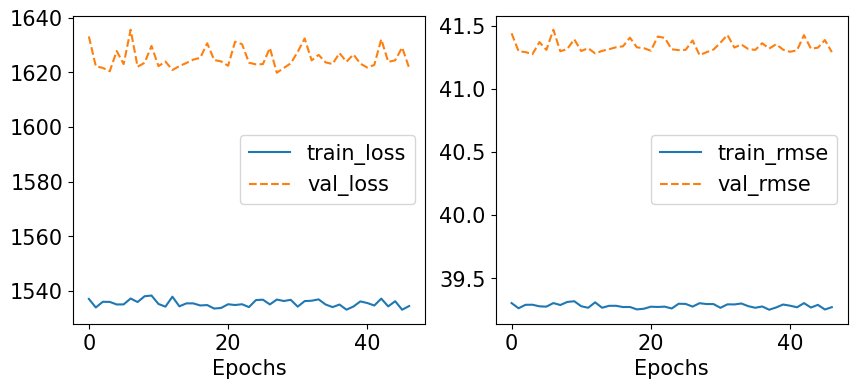

In [ ]:
training_plot(history);

In [ ]:
import matplotlib
matplotlib.rcParams.update({'font.size': 15})
def training_plot(history):
    f, ax = plt.subplots(1, 2, figsize=(10,4))
    ax[0].plot(history['train_loss'])
    ax[0].plot(history['val_loss'], ls='dashed')
    ax[1].plot(history['train_rmse'])
    ax[1].plot(history['val_rmse'], ls='dashed')
    ax[0].set_xlabel("Epochs")
    ax[1].set_xlabel("Epochs")
    ax[0].legend(['train_loss', 'val_loss'], fontsize=15)
    ax[1].legend(['train_rmse', 'val_rmse'], fontsize=15)

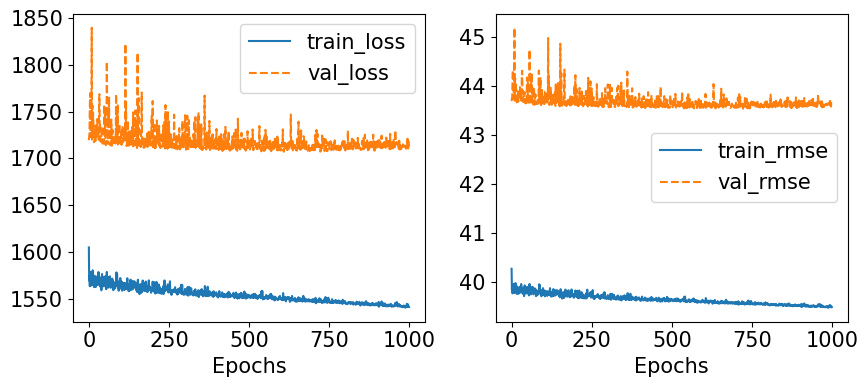

In [ ]:
training_plot(history);

In [ ]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

In [ ]:
indexes = [1, 2, 3, 4, 5, 6, 7, 8, 9]
X = train_data.iloc[:, indexes].values
y = train_data.iloc[:, 10].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(2959652, 9)
(328851, 9)


In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

In [ ]:
preprocessor.fit(X_train)
X_train = preprocessor.transform(X_train)
X_valid = preprocessor.transform(X_valid)

In [ ]:
!pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

# define the model
clf= TabNetRegressor(optimizer_fn=torch.optim.Adam,
                       scheduler_params={"step_size":10,
                                         "gamma":0.9},
                       scheduler_fn=torch.optim.lr_scheduler.StepLR,
                      )

# fit the model
clf.fit(
    X_train,y_train.reshape(-1,1),
    eval_set=[(X_train, y_train.reshape(-1,1)), (X_valid, y_valid.reshape(-1,1))],
    eval_name=['train', 'test'],
    eval_metric=['mse'],
    max_epochs=1, patience=60,
    batch_size=512, virtual_batch_size=512,
    num_workers=0,
    # weights=[1],
    drop_last=False
)

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1542.79074| train_mse: 1507.81569| test_mse: 1508.09979|  0:03:49s
Stop training because you reached max_epochs = 1 with best_epoch = 0 and best_test_mse = 1508.09979


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
y_pred = tabnet.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

86.63337679383206

In [ ]:
reg = BaggingRegressor(DecisionTreeRegressor(max_depth=2), warm_start=True)
reg_pipe = make_pipeline(preprocessor, reg)

In [ ]:
reg_pipe.fit(X_train, y_train);

In [ ]:
y_pred = reg_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.91007353981383

In [ ]:
boost = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
boost_pipe = make_pipeline(preprocessor, boost)

boost_pipe.fit(X_train, y_train);

y_pred = boost_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

KeyboardInterrupt: 

In [ ]:
import xgboost as xgb

xgb_pipe = make_pipeline(preprocessor, xgb)

xgb_pipe.fit(X_train, y_train);

y_pred = xgb_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

TypeError: 'module' object is not callable

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

clf = CatBoostClassifier(
    iterations=1,
    learning_rate=0.1,
    #loss_function='CrossEntropy'
)

cb_pipe = make_pipeline(preprocessor, clf)

In [ ]:
cb_pipe.fit(X_train, y_train);
y_pred = cb_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

## Move tresh

In [ ]:
import collections

bins = collections.defaultdict(list)
for ri, t in zip(X, y):
    bins[tuple(ri)].append(t)

In [ ]:
len(bins)

31334

In [ ]:
max(y)

150.0

In [ ]:
min(y)

15.0

## Authentic dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("souradippal/student-bag-price-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.23M/1.23M [00:00<00:00, 131MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/souradippal/student-bag-price-prediction-dataset/versions/1


In [ ]:
!mv /root/.cache/kagglehub/datasets/souradippal/student-bag-price-prediction-dataset/versions/1/Noisy_Student_Bag_Price_Prediction_Dataset.csv kaggle_dataset.csv

In [ ]:
kaggle_data = pd.read_csv("kaggle_dataset.csv")
kaggle_data

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Nylon,Small,2.0,No,Yes,Backpack,Green,13.340058,143.445135
1,Under Armour,Nylon,Large,4.0,Yes,Yes,Tote,Pink,5.918030,72.086319
2,Nike,Nylon,Large,NaN,No,Yes,Messenger,Red,24.088386,29.699631
3,Nike,Nylon,Small,1.0,Yes,No,Messenger,Pink,5.000000,27.181990
4,Under Armour,Leather,Small,8.0,Yes,No,NaN,Black,11.258172,71.953236
...,...,...,...,...,...,...,...,...,...,...
52495,Jansport,Nylon,Medium,3.0,No,Yes,Messenger,Gray,19.774853,61.140497
52496,Jansport,NaN,Small,8.0,No,Yes,Messenger,Red,29.822417,47.140186
52497,Jansport,Polyester,Large,10.0,No,Yes,Messenger,Red,13.269034,56.184138
52498,Adidas,Canvas,Large,5.0,No,No,Messenger,Green,28.132229,112.036966


In [ ]:
kaggle_data = kaggle_data[kaggle_data['Price'].notna()]
kaggle_data.insert(9, "Price_clusters", kaggle_data["Price"].values // 10)

In [ ]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputation_mean", SimpleImputer(missing_values=np.nan, strategy="mean")),
        ('poly', PolynomialFeatures(degree=3)),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputation_constant",
            SimpleImputer(fill_value="missing", strategy="constant"),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8]),
    ]
)

lr_pipe_orig = make_pipeline(preprocessor, LinearRegression())

In [ ]:
X = kaggle_data.iloc[:, :-2].values
y = kaggle_data.iloc[:, -2].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(44887, 9)
(4988, 9)


In [ ]:
lr_pipe_orig.fit(X_train, y_train);
y_pred = lr_pipe_orig.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

3.9356207138238433

In [ ]:
kaggle_data.insert(9, "Pred_price_clusters", lr_pipe_orig.predict(kaggle_data.iloc[:, :-2].values))

preprocessor_2 = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8, 9]),
    ]
)

lr_pipe_2 = make_pipeline(preprocessor_2, LinearRegression())

X = kaggle_data.iloc[:, :-2].values
y = kaggle_data.iloc[:, -1].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(44887, 10)
(4988, 10)


In [ ]:
lr_pipe_2.fit(X_train, y_train);
y_pred = lr_pipe_2.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

39.07725931213335

In [ ]:
train_data

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...,...
3694313,4194313,Nike,Canvas,NaN,3.0,Yes,Yes,Messenger,Blue,28.098120,104.74460
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,122.39043
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,148.18470
3694316,4194316,Puma,Canvas,NaN,2.0,No,No,Backpack,Gray,28.783339,22.32269


In [ ]:
# generated data
train_data.insert(10, "Pred_price_clusters", lr_pipe_orig.predict(train_data.iloc[:, 1:-1].values))

preprocessor_2 = ColumnTransformer(
    [
        ("categorical", categorical_preprocessor, [0, 1, 2, 4, 5, 6, 7]),
        ("numerical", numeric_preprocessor, [3, 8, 9]),
    ]
)

lr_pipe_2 = make_pipeline(preprocessor_2, LinearRegression())

X = train_data.iloc[:, 1:-1].values
y = train_data.iloc[:, -1].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(3594886, 10)
(399432, 10)


In [ ]:
lr_pipe_2.fit(X_train, y_train);
y_pred = lr_pipe_2.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

38.90582578286774

In [ ]:
X = kaggle_data.iloc[:, :-2].values
y = kaggle_data.iloc[:, -1].values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.1, random_state=SEED)

print(X_train.shape)
print(X_valid.shape)

(28226, 9)
(3137, 9)


In [ ]:
lr_pipe.fit(X_train, y_train);
y_pred = lr_pipe.predict(X_valid)
root_mean_squared_error(y_valid, y_pred)

39.20323907948381

## Test

In [ ]:
test_data = pd.read_csv("test.csv")
test_data.insert(10, "W+C", (test_data["Compartments"].values + test_data["Weight Capacity (kg)"].values).astype(float))
test_data.insert(11, "W*C", (test_data["Compartments"].values * test_data["Weight Capacity (kg)"].values).astype(float))
test_data["Price_clusters"] = lr_pipe.predict(test_data.iloc[:, 1:])
test_data

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),W+C,W*C,Price_clusters
0,300000,Puma,Leather,Small,2.0,No,No,Tote,Green,20.671147,22.671147,41.342293,3.595682
1,300001,Nike,Canvas,Medium,7.0,No,Yes,Backpack,Green,13.564105,20.564105,94.948732,3.642320
2,300002,Adidas,Canvas,Large,9.0,No,Yes,Messenger,Blue,11.809799,20.809799,106.288192,3.579269
3,300003,Adidas,Nylon,Large,1.0,Yes,No,Messenger,Green,18.477036,19.477036,18.477036,3.573177
4,300004,NaN,Nylon,Large,2.0,Yes,Yes,Tote,Black,9.907953,11.907953,19.815906,3.496839
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,499995,Adidas,Canvas,Large,2.0,Yes,No,Messenger,Red,7.383498,9.383498,14.766996,3.489894
199996,499996,Nike,Polyester,Small,9.0,No,Yes,Messenger,Pink,6.058394,15.058394,54.525550,3.464146
199997,499997,Jansport,Nylon,Small,9.0,No,Yes,Tote,Green,26.890163,35.890163,242.011471,3.632128
199998,499998,Puma,Nylon,Large,10.0,Yes,No,Tote,Gray,25.769153,35.769153,257.691529,3.544259


In [ ]:
y_pred_lr = lr_pipe.predict(test_data.iloc[:, 1:])
y_pred_boost = boost_pipe.predict(test_data.iloc[:, 1:])
y_pred_ens = np.mean([y_pred_boost, y_pred_lr], 0)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


In [ ]:
y_pred = lr_pipe_2.predict(test_data.iloc[:, 1:])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


In [ ]:
d = {'id': test_data["id"].values, 'Price': y_pred}
df = pd.DataFrame(d)

In [ ]:
df

,id,Price
0,300000,81.874251
1,300001,82.751742
2,300002,81.386170
3,300003,81.224059
4,300004,79.569121
...,...,...
199995,499995,79.332444
199996,499996,78.695147
199997,499997,82.652210
199998,499998,80.759071


In [ ]:
df.to_csv("lr_clusters_20.csv", index=False)